# Basic RAG Pipeline

A minimal Retrieval-Augmented Generation pipeline: load PDFs, split them into chunks, embed them into a FAISS vector store, and answer questions with a LangGraph retrieve → generate flow.

In [1]:
import logging

from typing import List, TypedDict

from langchain_pymupdf4llm import PyMuPDF4LLMLoader
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv

load_dotenv()

logging.getLogger("google_genai.models").setLevel(logging.ERROR)

## Load Documents

In [17]:
pdf_paths = ["../docs/book1.pdf","../docs/book2.pdf","../docs/book3.pdf"]

docs: List[Document] = []

for path in pdf_paths:
    docs.extend(PyMuPDF4LLMLoader(path).load())

len(docs)

2123

## Split into Chunks

In [29]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

len(chunks)

8279

## Embeddings & Vector Store

In [19]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vector_store = Chroma.from_documents(chunks, embeddings)

In [30]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

## LLM

In [31]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

## Graph State

In [32]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

## Nodes: Retrieve & Generate

In [33]:
def retrieve(state):
    question = state["question"]
    return {"docs": retriever.invoke(question)}

In [34]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer only from the context. If it is not in the context, say you don't know."),
    ("human", "Question: {question}\n\n{context}"),
])

In [35]:
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

## Build the Graph

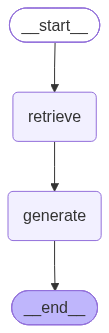

In [36]:
graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)
app = graph.compile()

graph.compile()

## Run

In [38]:
result = app.invoke({"question": "What is the deep learning?", "docs": [], "answer": ""})
print(result["answer"])

Deep learning is an approach to AI where concepts are built on top of each other, resulting in a deep graph with many layers. It solves the central problem in representation learning by introducing representations that are expressed in terms of other, simpler representations, allowing the computer to build complex concepts out of simpler concepts.

Deep learning can also be regarded as the study of models that either involve a greater amount of composition of learned functions or learned concepts than traditional machine learning does.


In [40]:
result = app.invoke({"question": "gradient decent ?", "docs": [], "answer": ""})
print(result["answer"])

Gradient Descent is a very generic optimization algorithm capable of finding optimal solutions to a wide range of problems. The general idea is to tweak parameters iteratively in order to minimize a cost function.

It works by measuring the local gradient of the error function with regards to the parameter vector, and then moving in the direction of descending gradient (the negative gradient). Once the gradient is zero, a minimum has been reached. This method is also known as the method of steepest descent. The simplest approach to using gradient information is to choose the weight update to comprise a small step in the direction of the negative gradient.


In [41]:
print(result['docs'][0].page_content)
print('*'*100)
print(result['docs'][1].page_content)
print('*'*100)
print(result['docs'][2].page_content)
print('*'*100)
print(result['docs'][3].page_content)

# **5.2.4 Gradient descent optimization** 

The simplest approach to using gradient information is to choose the weight update in (5.27) to comprise a small step in the direction of the negative gradient, so that
****************************************************************************************************
Download from finelybook www.finelybook.com 

# **Gradient Descent** 

_Gradient Descent_ is a very generic optimization algorithm capable of finding optimal solutions to a wide range of problems. The general idea of Gradient Descent is to tweak parameters iteratively in order to minimize a cost function. 

Suppose you are lost in the mountains in a dense fog; you can only feel the slope of the ground below your feet. A good strategy to get to the bottom of the valley quickly is to go downhill in the direction of the steepest slope. This is exactly what Gradient Descent does: it measures the local gradient of the error function with regards to the parameter vector _θ_ , and it 